# Guided Numeric Exploration — Full-Spectrum Quantitative (Ni Alloys)
_Composition space of nickel-based alloy samples from a small quantitative table_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [willianoliveiragibin/full-spectrum-quantitative](https://www.kaggle.com/datasets/willianoliveiragibin/full-spectrum-quantitative)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Univariate Composition](#Univariate)** <br>
**4. [Pairwise Element Relationships](#Pairs)** <br>
**5. [PCA Composition Map](#PCA)** <br>
**6. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
The CSV is a **tiny materials composition table** (n=32) with percent shares of `Co`, `Cr`, `Mo`, `Ni`, and a residual **Other elemental impurities** bucket. Rows sum to ~100% — a closed compositional system.

**Data-card caveat:** the Kaggle description discusses PGNAA assay of Hg/Cd/Pb in concrete matrices, which does **not** match these columns. This notebook analyzes the CSV as Ni-alloy composition percentages and treats the card text as mismatched metadata.

With only 32 samples, every plot is descriptive. I will not invent a large-sample story.


# **2. Setup and Data Peek:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances, PCA), not a production model. `kagglehub` resolves files both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read and Peak at Data
CSV_BASENAME = "Full-Spectrum-Quantitative new.csv"
KAGGLE_SLUG = "willianoliveiragibin/full-spectrum-quantitative"
ELEM_RAW = ["Co", "Cr", "Mo", "Ni", "Other elemental impurities(Al,Fe,Nb,Ta,Ti,et)"]
ELEM = ["Co", "Cr", "Mo", "Ni", "Other"]


def parse_eu_number(x) -> float:
    """Parse European decimal commas and scientific notation like 1,37E-07."""
    if pd.isna(x):
        raise AssertionError("unexpected null in composition cell")
    if isinstance(x, (int, float, np.floating, np.integer)):
        return float(x)
    s = str(x).strip().replace(" ", "").replace(",", ".")
    return float(s)


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(CSV_BASENAME):
            return p
        hits = list(kaggle_root.rglob("*Quantitative*.csv"))
        assert hits, "no quantitative csv under /kaggle/input"
        return hits[0]
    local_data = Path("data") / CSV_BASENAME
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    hits = list(root.rglob(CSV_BASENAME))
    assert hits, f"expected {CSV_BASENAME} under {root}"
    return hits[0]


csv_path = resolve_csv_path()
print("CSV:", csv_path)
raw = pd.read_csv(csv_path, low_memory=False)
assert len(raw) == 32, f"expected 32 rows, got {len(raw)}"
missing = set(ELEM_RAW) - set(raw.columns)
assert not missing, f"missing element cols: {sorted(missing)}"

df = raw.copy()
for src, dst in zip(ELEM_RAW, ELEM):
    df[dst] = df[src].map(parse_eu_number)
df["comp_sum"] = df[ELEM].sum(axis=1)
assert np.allclose(df["comp_sum"], 100.0, atol=1e-3), df["comp_sum"].describe()

unique_count = [[c, df[c].nunique(dropna=False), int(df[c].isnull().sum())] for c in df.columns]
print("Missing Values:", df[ELEM].isnull().sum().sum())
print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
print("Composition sum — min/max:", round(df["comp_sum"].min(), 6), round(df["comp_sum"].max(), 6))


  0%|          | 0.00/1.07k [00:00<?, ?B/s]

100%|██████████| 1.07k/1.07k [00:00<00:00, 1.15MB/s]

Extracting files...


CSV: /Users/nicapotato/.cache/kagglehub/datasets/willianoliveiragibin/full-spectrum-quantitative/versions/1/Full-Spectrum-Quantitative new.csv
Missing Values: 0
Dataframe Dimension: 32 Rows, 9 Columns
Composition sum — min/max: 99.9999 100.0001


**Code Explanation and Reasoning:** <br>
European comma decimals are parsed explicitly; asserts require n=32 and composition sums ≈ 100%. Failing loud here prevents silent percent-scale mistakes later.


In [3]:
df.sample(5, random_state=7)


,编号,Sample No.,Co,Cr,Mo,Ni,"Other elemental impurities(Al,Fe,Nb,Ta,Ti,et)",Other,comp_sum
2,29,3,8.1284,12.6336,8.6499,52.7402,"17,8479",17.8479,100.0000
26,11,27,3.3283,17.7586,2.6920,65.2153,"11,0059",11.0059,100.0001
1,36,2,14.1646,12.2121,4.1948,52.3577,"17,0708",17.0708,100.0000
9,22,10,8.0935,16.9112,3.3295,56.8597,"14,8061",14.8061,100.0000
13,6,14,5.1055,16.0286,6.2446,57.6743,"14,9470",14.9470,100.0000


In [4]:
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Null"]))
df[ELEM].describe().T.round(3)


,Column,Unique,Null
0,编号,32,0
1,Sample No.,32,0
2,Co,32,0
3,Cr,32,0
4,Mo,32,0
5,Ni,32,0
6,"Other elemental impurities(Al,Fe,Nb,Ta,Ti,et)",32,0
7,Other,32,0
8,comp_sum,7,0


,count,mean,std,min,25%,50%,75%,max
Co,32.0,6.311,2.990,1.061,4.397,5.250,8.427,14.165
Cr,32.0,16.234,2.712,11.451,13.911,16.562,18.107,23.022
Mo,32.0,4.302,2.700,1.106,2.747,3.713,5.601,12.444
Ni,32.0,60.070,4.965,52.071,56.489,60.148,63.864,69.622
Other,32.0,13.083,4.970,3.421,8.868,13.275,17.139,22.684


**Interpretation** <br>
Ni typically dominates; Co/Cr/Mo and Other fill the remainder. Because compositions are closed (sum to 100%), pairwise correlations are partly mechanical — more Ni leaves less room for everything else.


# **3. Univariate Composition:** <a id="Univariate"></a>


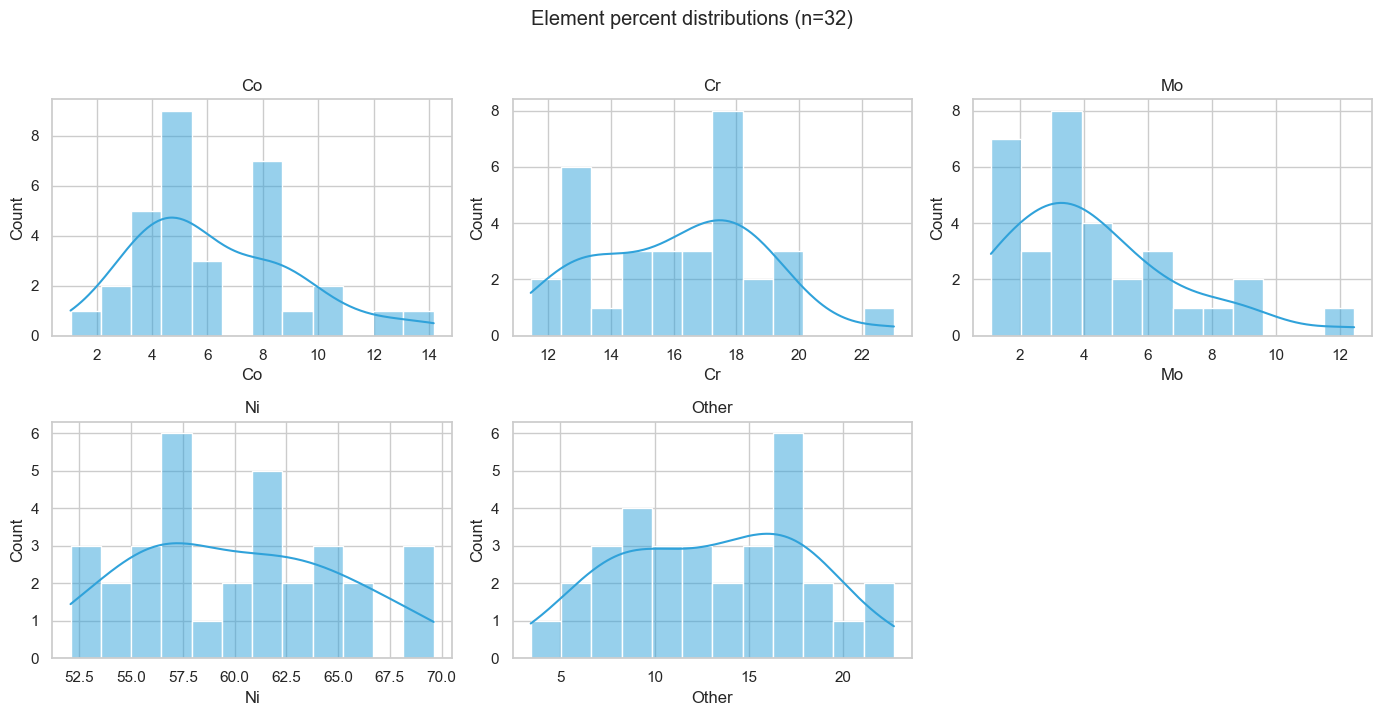

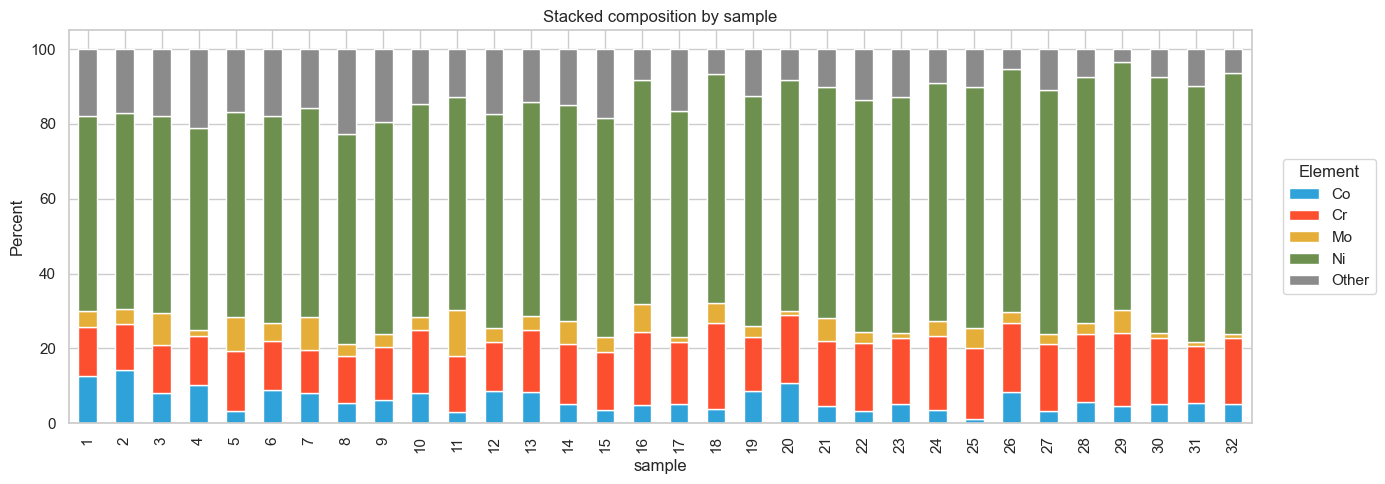

In [5]:
f, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()
for i, col in enumerate(ELEM):
    sns.histplot(df[col], bins=12, kde=True, ax=axes[i], color="#30a2da")
    axes[i].set_title(col)
axes[-1].axis("off")
plt.suptitle("Element percent distributions (n=32)", y=1.02)
plt.tight_layout()
plt.show()

# Stacked composition for a readable sample of rows
plot_df = df[ELEM].copy()
plot_df["sample"] = df.iloc[:, 1].astype(str) if df.columns[1] != "Co" else np.arange(1, len(df) + 1).astype(str)
# use Sample No. if present
if "Sample No." in df.columns:
    plot_df["sample"] = df["Sample No."].astype(str)
plot_df = plot_df.set_index("sample")
ax = plot_df.plot(kind="bar", stacked=True, figsize=(14, 5),
                  color=["#30a2da", "#fc4f30", "#e5ae38", "#6d904f", "#8b8b8b"])
ax.set_ylabel("Percent")
ax.set_title("Stacked composition by sample")
ax.legend(title="Element", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
Histograms show which elements vary vs sit near a constant recipe. Stacked bars make alloy 'recipes' comparable sample-to-sample; watch for impurity spikes in Other.


# **4. Pairwise Element Relationships:** <a id="Pairs"></a>


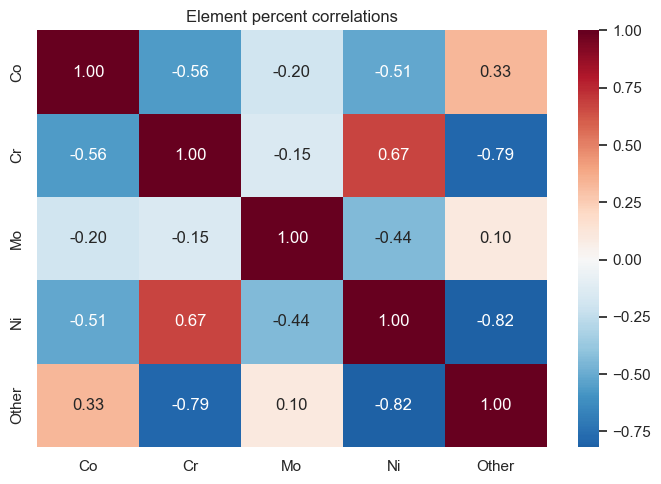

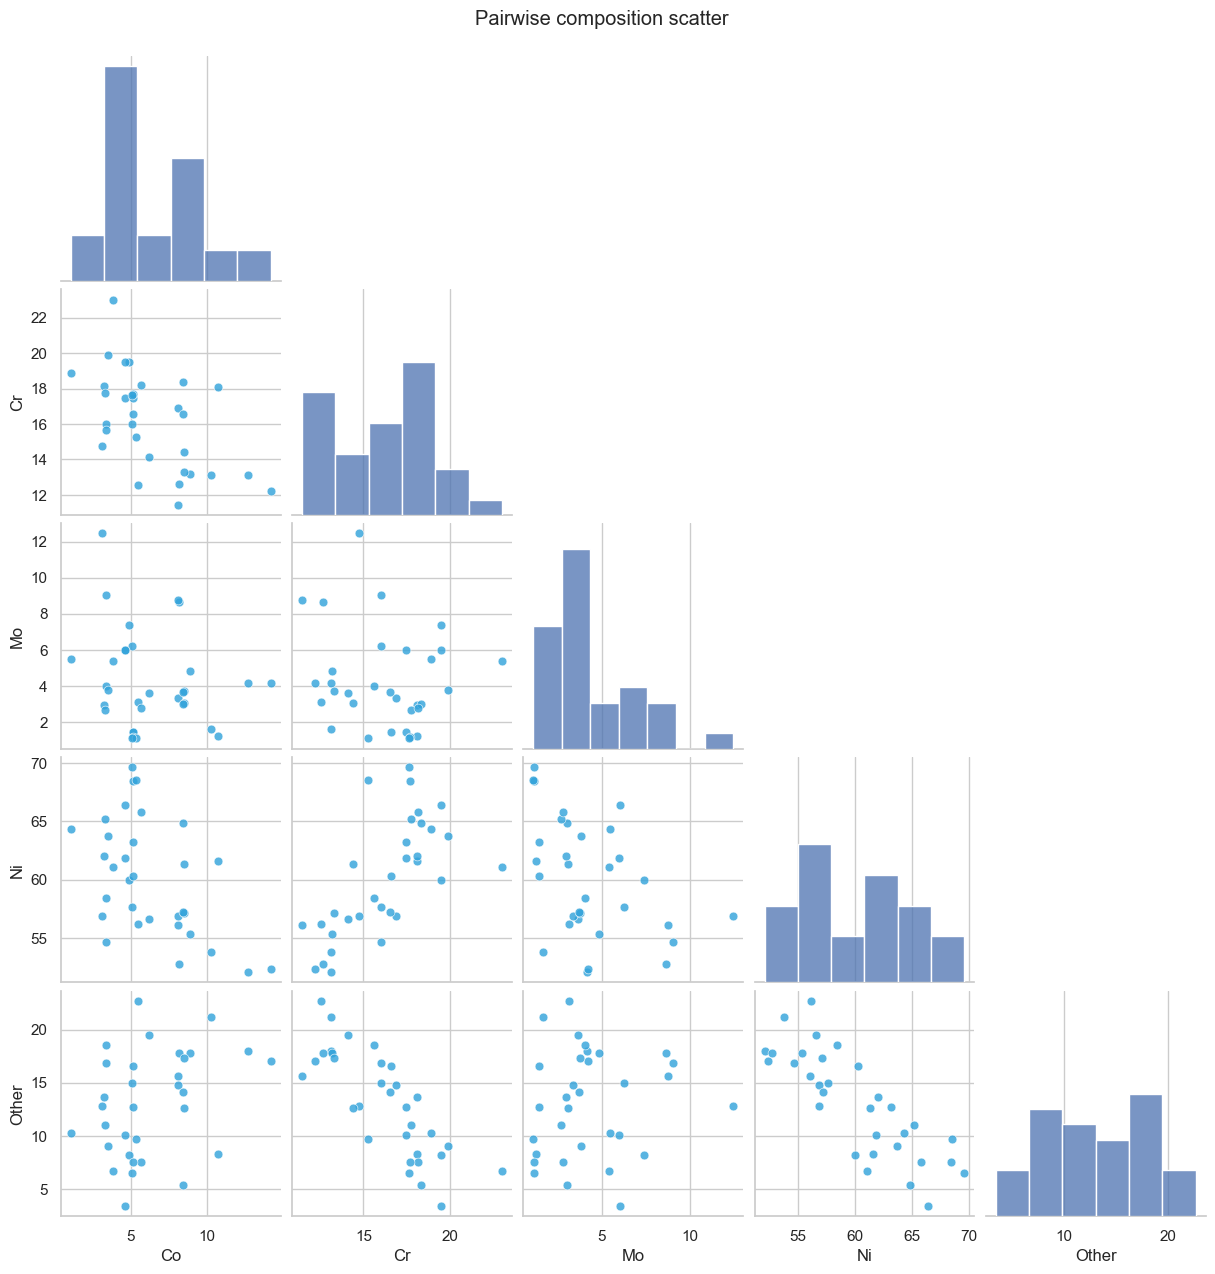

In [6]:
corr = df[ELEM].corr()
f, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Element percent correlations")
plt.tight_layout()
plt.show()

sns.pairplot(df[ELEM], corner=True, plot_kws={"s": 40, "alpha": 0.8, "color": "#30a2da"})
plt.suptitle("Pairwise composition scatter", y=1.02)
plt.show()


**How to Interpret:** <br>
Negative Ni correlations with other elements are expected in a closed simplex. Look instead for Co–Cr–Mo structure among the alloying elements and whether Other impurities track a particular major metal.


# **5. PCA Composition Map:** <a id="PCA"></a>


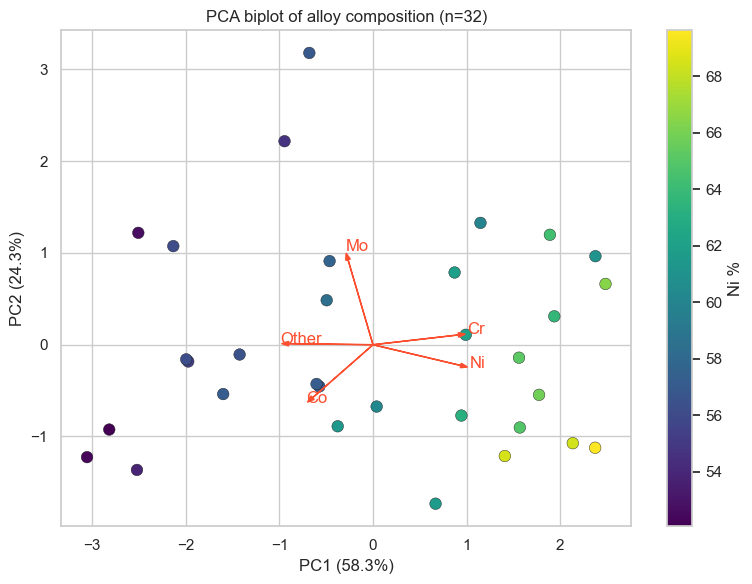

Explained variance ratio: [0.583 0.243]


In [7]:
X = StandardScaler().fit_transform(df[ELEM])
pca = PCA(n_components=2, random_state=7)
Z = pca.fit_transform(X)
pc = pd.DataFrame(Z, columns=["PC1", "PC2"])
pc["Ni"] = df["Ni"].values
pc["Other"] = df["Other"].values

f, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(pc["PC1"], pc["PC2"], c=pc["Ni"], cmap="viridis", s=70, edgecolor="k", linewidth=0.3)
cb = plt.colorbar(sc, ax=ax)
cb.set_label("Ni %")
# loadings
load = pca.components_.T * np.sqrt(pca.explained_variance_)
for i, name in enumerate(ELEM):
    ax.arrow(0, 0, load[i, 0], load[i, 1], color="#fc4f30", width=0.002, head_width=0.05)
    ax.text(load[i, 0] * 1.1, load[i, 1] * 1.1, name, color="#fc4f30")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA biplot of alloy composition (n=32)")
plt.tight_layout()
plt.show()
print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))


**How to Interpret:** <br>
Points are samples in standardized composition space; arrows are element loadings. With n=32 this is an exploratory map, not a clustering proof. Outliers far from the cloud deserve a manual look at their raw percents.


# **6. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
Thirty-two closed compositions for Ni-based alloys (Co/Cr/Mo/Ni/Other), despite a mismatched PGNAA data-card narrative.

**Working takeaways:** <br>
- Always parse European decimals before any numeric EDA.
- Compositional closure drives much of the correlation structure.
- PCA is useful for spotting odd recipes, not for claiming latent physics with this n.

**Open follow-ups:** <br>
- Log-ratio (Aitchison) transforms for compositional data.
- Link samples to process/batch metadata if a better source table exists.
